# 21 — Nonlinear orthogonality: is there hidden image structure the linear test missed?

Review task 1. The claim "no hidden cell states" rested on ridge regression (notebook 04, `run_celltype`): the
transcriptome explains a median ~15 % of each image feature, and the rest is mostly a local optical field. Ridge can
only find *linearly* accessible structure, while notebook 08 showed gradient-boosted trees recognise 14 cell types from
images alone (balanced accuracy 0.46), so images carry nonlinearly accessible identity information.

Here the same analysis with `run_celltype_nonlinear` (`src/beyondboundaries/orthogonality.py`):
HistGradientBoostingRegressor instead of RidgeCV for the covariate (`cov`), covariate + transcriptome (`full`) and
transcriptome-only (`tx`) models. **Everything else is identical to notebook 04**: runs 5/6, 18S-segmented cells,
the same cell types (≥ 500 cells, ≥ 5 animals), the same 30,000-cell cap with the same seeded subsample, the same
118 features (those with < 5 % missing per type), rank-inverse-normal targets, 5-fold GroupKFold by animal, 50
transcriptome PCs fitted on the training folds only, pooled out-of-fold R², ΔR²(tx | cov) floored at zero.

**Question:** is nonlinear ΔR²(tx | cov) materially larger than linear? If not, "no hidden cell states" stands; if so,
it must be weakened to "no *linearly* accessible hidden states".

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")  # one thread per tree model; parallelism over features via joblib
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth

plotting.style()
SRC = "notebooks/21_nonlinear_orthogonality.ipynb"
OUT = ROOT / "results" / "21_nonlinear_orthogonality"
OUT.mkdir(parents=True, exist_ok=True)
LIN = ROOT / "data" / "residuals"               # notebook 04 cache (linear)
NL = ROOT / "data" / "residuals_nonlinear"
NL.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
MIN_CELLS, MIN_ANIMALS, MAX_CELLS = 500, 5, 30000
rng = np.random.default_rng(0)                  # same seed and draw order as notebook 04

## Same cells and features as notebook 04

In [2]:
fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
for ch in CH:
    fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
                                (fa[f"{ch}_ring_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"])
f = fa[(fa.segmentation_method == "Segmented by interior stain (18S)")
       & ~fa.Anno_L1_curated.isin(["Doublet", "T_B_doublet"])].copy()
FEATS = []
for ch in CH:
    FEATS += [f"{ch}_{c}_{s}" for c in ("nuc", "cyto", "rim", "ring", "terr") for s in ("mean", "p90")]
    FEATS += [f"{ch}_radial_b{k}" for k in range(5)]
    FEATS += [f"{ch}_polarity_shape", f"{ch}_polarity_nuc", f"{ch}_rim_over_ring"]
    FEATS += [f"{ch}_glcm_{k}" for k in ("contrast", "homogeneity", "asm", "entropy", "correlation")]
FEATS += [c for c in f.columns if c.startswith("morph_") and c != "morph_cell_orientation"] + ["nuc_offset"]
n_by = f.groupby("Anno_L1_curated", observed=True).agg(n=("section_id", "size"), animals=("sample_name", "nunique"))
TYPES = n_by[(n_by.n >= MIN_CELLS) & (n_by.animals >= MIN_ANIMALS)].sort_values("n", ascending=False).index.tolist()
cfg = data.load_config()
adata = ad.read_h5ad(ROOT / cfg["annotation"]["h5ad"])
print(len(FEATS), "image features;", len(TYPES), "cell types:", TYPES)

105 image features; 14 cell types: ['Oligodendrocyte', 'Myeloid', 'Neuron', 'Fibroblast', 'Astrocyte', 'Endothelial', 'Schwann cell', 'DC', 'T cell', 'OPC', 'VSMC', 'B cell', 'Ependymal cell', 'NK/DC']


## Fit the nonlinear arm (cached in `data/residuals_nonlinear/`)
The subsample check confirms the cells are the ones notebook 04 used (same index as its cached residuals).

In [3]:
nonlin, lin = {}, {}
for t in TYPES:
    tag = t.replace("/", "_").replace(" ", "_")
    d = f[f.Anno_L1_curated == t]
    if len(d) > MAX_CELLS:
        d = d.loc[rng.choice(d.index.values, MAX_CELLS, replace=False)]
    feats = [c for c in FEATS if d[c].isna().mean() < 0.05]
    lin[t] = pd.read_pickle(LIN / f"{tag}.pkl")
    assert lin[t]["residuals"].index.equals(d.index), f"{t}: subsample differs from notebook 04"
    cache = NL / f"{tag}.pkl"
    if cache.exists():
        nonlin[t] = pd.read_pickle(cache)
        continue
    r = orth.run_celltype_nonlinear(d, adata[d.index].X, feats, n_jobs=8)
    r["n"] = len(d)
    pd.to_pickle(r, cache)
    nonlin[t] = r
    print(f"{t}: n = {len(d)}, median ΔR²(tx|cov) linear {lin[t]['r2']['tx_unique'].median():.3f} → "
          f"nonlinear {r['r2']['tx_unique'].median():.3f}", flush=True)

## Linear vs nonlinear, per cell type

In [4]:
rows = []
for t in TYPES:
    L, N = lin[t]["r2"], nonlin[t]["r2"].reindex(lin[t]["r2"].index)
    dd = (N.tx_unique - L.tx_unique).dropna()
    rows.append(dict(cell_type=t, n_cells=nonlin[t]["n"], features=len(dd),
                     linear_dR2_tx=L.tx_unique.median(), nonlinear_dR2_tx=N.tx_unique.median(),
                     difference=dd.median(), share_features_nonlinear_higher=(dd > 0).mean(),
                     linear_R2_full=L.full.median(), nonlinear_R2_full=N.full.median(),
                     linear_R2_cov=L["cov"].median(), nonlinear_R2_cov=N["cov"].median(),
                     nonlinear_unexplained=1 - N.full.median()))
cmp_ = pd.DataFrame(rows).set_index("cell_type")
cmp_.to_csv(OUT / "linear_vs_nonlinear_by_celltype.csv")
cmp_.round(3)

,n_cells,features,linear_dR2_tx,nonlinear_dR2_tx,difference,share_features_nonlinear_higher,linear_R2_full,nonlinear_R2_full,linear_R2_cov,nonlinear_R2_cov,nonlinear_unexplained
cell_type,,,,,,,,,,,
Oligodendrocyte,30000,105,0.090,0.086,-0.005,0.343,0.152,0.183,0.048,0.087,0.817
Myeloid,30000,105,0.105,0.082,-0.008,0.343,0.163,0.200,0.055,0.097,0.800
Neuron,30000,104,0.072,0.079,0.001,0.529,0.127,0.153,0.035,0.068,0.847
Fibroblast,30000,105,0.068,0.067,-0.006,0.352,0.123,0.156,0.042,0.069,0.844
Astrocyte,30000,105,0.071,0.064,-0.003,0.381,0.177,0.195,0.081,0.106,0.805
Endothelial,30000,105,0.075,0.081,-0.002,0.457,0.156,0.188,0.063,0.090,0.812
Schwann cell,20686,105,0.068,0.060,-0.012,0.343,0.112,0.163,0.029,0.089,0.837
DC,16866,85,0.080,0.075,-0.013,0.282,0.165,0.183,0.048,0.088,0.817
T cell,15921,85,0.091,0.070,-0.016,0.153,0.171,0.211,0.052,0.098,0.789


In [5]:
w = wilcoxon(cmp_.nonlinear_dR2_tx - cmp_.linear_dR2_tx)
print(f"over {len(cmp_)} cell types: median ΔR²(tx|cov) linear {cmp_.linear_dR2_tx.median():.3f}, nonlinear "
      f"{cmp_.nonlinear_dR2_tx.median():.3f}; median per-type difference {cmp_.difference.median():+.3f} "
      f"(Wilcoxon p = {w.pvalue:.2g}); median R²_full linear {cmp_.linear_R2_full.median():.3f}, "
      f"nonlinear {cmp_.nonlinear_R2_full.median():.3f}")

over 14 cell types: median ΔR²(tx|cov) linear 0.072, nonlinear 0.068; median per-type difference -0.009 (Wilcoxon p = 0.0085); median R²_full linear 0.150, nonlinear 0.170


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/21_nonlinear_orthogonality/linear_vs_nonlinear.png')

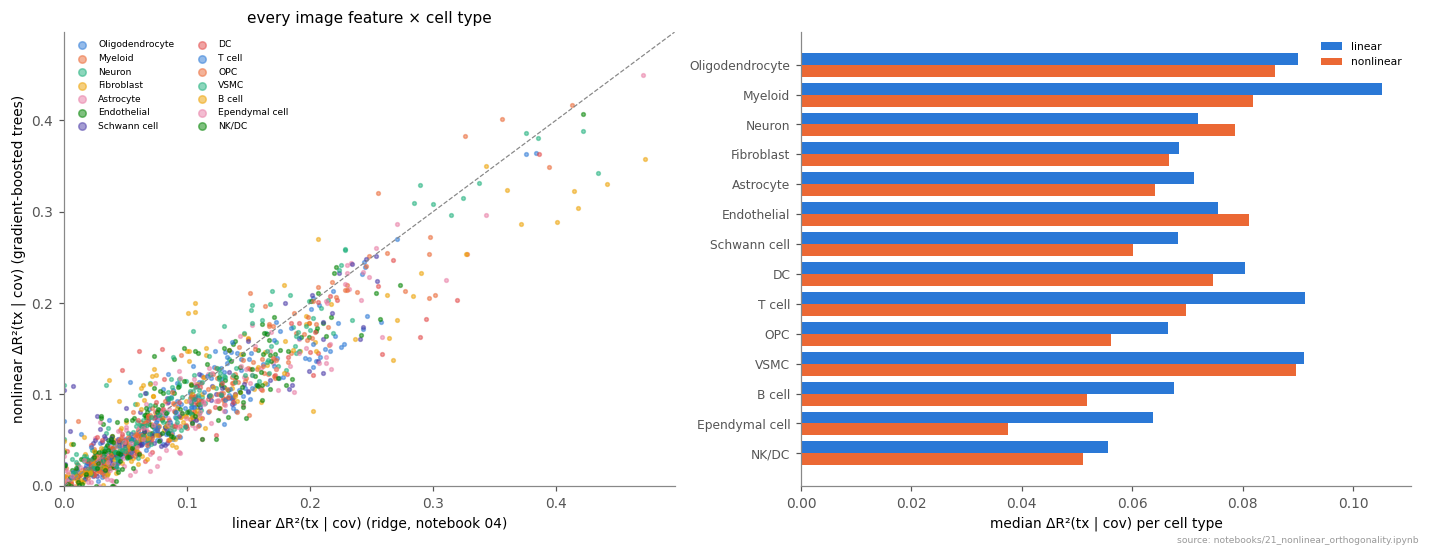

In [6]:
allf = pd.concat({t: pd.DataFrame({"linear": lin[t]["r2"].tx_unique,
                                   "nonlinear": nonlin[t]["r2"].tx_unique.reindex(lin[t]["r2"].index)})
                  for t in TYPES}, names=["cell_type", "feature"]).reset_index()
fam = data.feature_families(allf.feature.unique())
allf["family"] = allf.feature.map(fam).fillna("other")
allf.to_csv(OUT / "linear_vs_nonlinear_by_feature.csv", index=False)
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for k, t in enumerate(TYPES):
    d = allf[allf.cell_type == t]
    axs[0].scatter(d.linear, d.nonlinear, s=6, alpha=0.5, color=plotting.CATEGORICAL[k % 8], label=t)
lim = [0, max(allf[["linear", "nonlinear"]].max().max(), 0.05) * 1.05]
axs[0].plot(lim, lim, color="#888888", ls="--", lw=0.8)
axs[0].set(xlabel="linear ΔR²(tx | cov) (ridge, notebook 04)", ylabel="nonlinear ΔR²(tx | cov) (gradient-boosted trees)",
           title="every image feature × cell type", xlim=lim, ylim=lim)
axs[0].legend(fontsize=6, ncol=2, markerscale=2)
y = np.arange(len(cmp_))
axs[1].barh(y - 0.2, cmp_.linear_dR2_tx, 0.4, color=plotting.CATEGORICAL[0], label="linear")
axs[1].barh(y + 0.2, cmp_.nonlinear_dR2_tx, 0.4, color=plotting.CATEGORICAL[1], label="nonlinear")
axs[1].set_yticks(y, cmp_.index, fontsize=8); axs[1].invert_yaxis()
axs[1].set_xlabel("median ΔR²(tx | cov) per cell type")
axs[1].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "linear_vs_nonlinear", OUT, SRC)

In [7]:
by_fam = allf.groupby("family")[["linear", "nonlinear"]].median()
by_fam["difference"] = by_fam.nonlinear - by_fam.linear
by_fam.sort_values("difference").round(3)

,linear,nonlinear,difference
family,,,
intensity: rim,0.128,0.110,-0.019
radial profile,0.069,0.052,-0.017
intensity: cyto,0.137,0.120,-0.016
texture (Haralick),0.059,0.051,-0.008
polarity,0.028,0.024,-0.004
intensity: nuc,0.114,0.110,-0.003
intensity: ring,0.050,0.049,-0.001
morphology,0.106,0.105,-0.001
intensity: terr,0.050,0.051,0.001


## Joint tests: the image features *together*
The per-feature test above asks how much of each image feature the transcriptome explains. A hidden cell state could
instead be a *combination* of image features. Three joint tests on the same cells (runs 5/6, notebook 04 subsample):

- **J1. Clustering of the nonlinear residuals** (all features at once; Leiden on PCA, resolution 0.3, as notebook 04).
  A real hidden state would be a cluster tied to lesion state or disease, not to one image or animal.
- **J2. Reverse, nonlinear:** all image features together predicting the cell's transcriptome PCs (20 PCs per type, as
  notebook 04), gradient-boosted trees vs ridge; ΔR² over covariates.
- **J3. Do images add to the RNA?** (a) lesion vs physiological per cell type from RNA (50 fold-fitted PCs) +
  covariates, with or without all image features (AUROC); lesion niches are RNA-defined, which biases towards RNA.
  (b) clinical score at sacrifice, run 5 cells only (one run, so the images' run signature can't help), per held-out
  animal (Spearman ρ over animals), RNA vs RNA + images.
All GroupKFold by animal (5 folds).

In [8]:
import scanpy as sc
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

f["lesion"] = f.Curated_niche_state.astype(str).str.startswith("Lesion")
f["phys"] = f.Curated_niche_state.astype(str) == "Physiological"
f["lesion_dist_um"] = orth.lesion_distance(f, f.lesion.values)
rng_j = np.random.default_rng(0)
cells = {}
for t in TYPES:  # re-derive the same subsample (same seed and order as above / notebook 04)
    d = f[f.Anno_L1_curated == t]
    if len(d) > MAX_CELLS:
        d = d.loc[rng_j.choice(d.index.values, MAX_CELLS, replace=False)]
    assert d.index.equals(lin[t]["residuals"].index)
    cells[t] = d


def bh(p):
    p = np.asarray(p, float); o = np.argsort(p)
    q = p[o] * len(p) / np.arange(1, len(p) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q); out[o] = np.minimum(q, 1)
    return out

### J1. Clustering of the nonlinear residuals

In [9]:
rows = []
for t in TYPES:
    res = nonlin[t]["residuals"]
    meta = f.loc[res.index, ["sample_name", "lesion", "phys", "lesion_dist_um", "section_id"]]
    a_ = ad.AnnData(res.values.astype(np.float32), obs=meta)
    sc.pp.pca(a_, n_comps=min(15, res.shape[1] - 1))
    sc.pp.neighbors(a_, n_neighbors=15)
    sc.tl.leiden(a_, resolution=0.3, flavor="igraph", n_iterations=2, key_added="rc", random_state=0)
    lab = a_.obs.rc.astype(str)
    for k in sorted(lab.unique(), key=int):
        mk = (lab == k).values
        if mk.sum() < 100:
            continue
        per = a_.obs.assign(k=mk).groupby("sample_name", observed=True).apply(
            lambda g: pd.Series({"L": g.k[g.lesion].mean() if g.lesion.sum() >= 20 else np.nan,
                                 "P": g.k[g.phys].mean() if g.phys.sum() >= 20 else np.nan}), include_groups=False).dropna()
        sec_share = a_.obs.section_id[mk].value_counts(normalize=True).iloc[0]
        an_share = a_.obs.sample_name[mk].value_counts(normalize=True).iloc[0]
        rows.append(dict(cell_type=t, cluster=k, n=int(mk.sum()), frac=mk.mean(), largest_image_share=sec_share,
                         largest_animal_share=an_share, lesion_minus_phys=(per.L - per.P).median() if len(per) else np.nan,
                         p=wilcoxon(per.L - per.P).pvalue if len(per) >= 5 else np.nan))
j1 = pd.DataFrame(rows)
j1["q"] = bh(j1.p.fillna(1))
j1.to_csv(OUT / "J1_residual_clusters_nonlinear.csv", index=False)
lin_cl = pd.read_csv(ROOT / "results" / "04_orthogonality" / "residual_clusters.csv")
summary_j1 = pd.DataFrame({
    "clusters (≥ 100 cells), linear residuals": lin_cl.groupby("cell_type").size(),
    "clusters (≥ 100 cells), nonlinear residuals": j1.groupby("cell_type").size(),
    "lesion-associated (q < 0.05), linear": lin_cl[lin_cl.q < 0.05].groupby("cell_type").size(),
    "lesion-associated (q < 0.05), nonlinear": j1[j1.q < 0.05].groupby("cell_type").size(),
}).reindex(TYPES).fillna(0).astype(int)
summary_j1

/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,"clusters (≥ 100 cells), linear residuals","clusters (≥ 100 cells), nonlinear residuals","lesion-associated (q < 0.05), linear","lesion-associated (q < 0.05), nonlinear"
cell_type,,,,
Oligodendrocyte,1,2,0,0
Myeloid,1,1,0,0
Neuron,1,1,0,0
Fibroblast,2,2,0,0
Astrocyte,1,1,0,0
Endothelial,2,2,0,2
Schwann cell,2,3,0,0
DC,2,1,0,0
T cell,1,2,0,0


In [10]:
j1.sort_values("q").round(3).head(15)

,cell_type,cluster,n,frac,largest_image_share,largest_animal_share,lesion_minus_phys,p,q
7,Endothelial,0,29601,0.987,0.082,0.082,-0.012,0.001,0.009
8,Endothelial,1,399,0.013,0.158,0.140,0.012,0.001,0.009
4,Fibroblast,0,17175,0.572,0.081,0.082,-0.020,0.165,0.495
5,Fibroblast,1,12825,0.428,0.116,0.112,0.020,0.165,0.495
14,T cell,1,6694,0.420,0.143,0.239,0.053,0.123,0.495
13,T cell,0,9227,0.580,0.107,0.198,-0.053,0.123,0.495
11,Schwann cell,2,2190,0.106,0.128,0.128,-0.009,0.165,0.495
0,Oligodendrocyte,0,20167,0.672,0.077,0.087,-0.012,0.922,1.000
18,B cell,1,2219,0.488,0.230,0.217,NaN,NaN,1.000
17,B cell,0,2329,0.512,0.207,0.188,NaN,NaN,1.000


### J2. Reverse, nonlinear: all image features → transcriptome PCs

In [11]:
rows = []
for t in TYPES:
    tag = t.replace("/", "_").replace(" ", "_")
    cache = NL / f"{tag}_reverse.pkl"
    d = cells[t]
    feats = list(lin[t]["r2"].index)
    if cache.exists():
        rev = pd.read_pickle(cache)
    else:
        Y = orth.rank_int(d[feats]).values.astype(np.float32)
        C = orth.covariates(d, True)
        Xln = orth.lognorm(adata[d.index].X)
        T = PCA(20, svd_solver="covariance_eigh", random_state=0).fit_transform(Xln)
        T = (T / T.std(0)).astype(np.float32)
        oof = {k: np.zeros_like(T) for k in ("cov", "full")}
        for tr, te in GroupKFold(5).split(T, groups=d.sample_name.astype(str).values):
            oof["cov"][te] = orth._hgb(C[tr], T[tr], C[te], 8)
            oof["full"][te] = orth._hgb(np.c_[C[tr], Y[tr]], T[tr], np.c_[C[te], Y[te]], 8)
        rev = pd.DataFrame({"cov": orth.r2(T, oof["cov"]), "full": orth.r2(T, oof["full"])},
                           index=[f"PC{i + 1}" for i in range(20)])
        rev["img_unique"] = orth._gain(rev.full, rev["cov"])
        pd.to_pickle(rev, cache)
    lr = lin[t]["reverse_pcs"]
    rows.append(dict(cell_type=t, linear_img_unique_median=lr.img_unique.median(), nonlinear_img_unique_median=rev.img_unique.median(),
                     linear_PC1=lr.img_unique.iloc[0], nonlinear_PC1=rev.img_unique.iloc[0]))
j2 = pd.DataFrame(rows).set_index("cell_type")
j2.to_csv(OUT / "J2_reverse_nonlinear.csv")
print(f"median over types: image → transcriptome PCs ΔR², linear {j2.linear_img_unique_median.median():.3f}, "
      f"nonlinear {j2.nonlinear_img_unique_median.median():.3f}")
j2.round(3)

/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


...

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


median over types: image → transcriptome PCs ΔR², linear 0.021, nonlinear 0.045


,linear_img_unique_median,nonlinear_img_unique_median,linear_PC1,nonlinear_PC1
cell_type,,,,
Oligodendrocyte,0.018,0.054,0.350,0.317
Myeloid,0.015,0.060,0.040,0.139
Neuron,0.026,0.065,0.361,0.305
Fibroblast,0.030,0.043,0.198,0.189
Astrocyte,0.021,0.073,0.411,0.400
Endothelial,0.036,0.061,0.279,0.275
Schwann cell,0.029,0.043,0.312,0.344
DC,0.022,0.051,0.064,0.159
T cell,0.010,0.026,0.205,0.188


### J3. Do images add to the RNA?

In [12]:
def clf_oof(X, y, groups):
    p = np.zeros(len(y))
    for tr, te in GroupKFold(5).split(X, groups=groups):
        m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, early_stopping=True, random_state=0,
                                           class_weight="balanced").fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p


rows = []
for t in TYPES:
    tag = t.replace("/", "_").replace(" ", "_")
    cache = NL / f"{tag}_J3a.pkl"
    d = cells[t]
    keep = (d.lesion | d.phys).values
    if keep.sum() < 500 or d.lesion[keep].mean() < 0.05 or d.lesion[keep].mean() > 0.95:
        continue
    if cache.exists():
        r = pd.read_pickle(cache)
    else:
        feats = list(lin[t]["r2"].index)
        dd = d[keep]
        Y = orth.rank_int(dd[feats]).values.astype(np.float32)
        C = orth.covariates(dd, True)
        Xln = orth.lognorm(adata[dd.index].X)
        y = dd.lesion.values.astype(int)
        g = dd.sample_name.astype(str).values
        p_rna, p_both = np.zeros(len(y)), np.zeros(len(y))
        for tr, te in GroupKFold(5).split(Y, groups=g):
            pca = PCA(50, svd_solver="covariance_eigh", random_state=0).fit(Xln[tr])
            P = np.zeros((len(y), 50), np.float32)
            P[tr], P[te] = pca.transform(Xln[tr]), pca.transform(Xln[te])
            for X_, out in ((np.c_[C, P], p_rna), (np.c_[C, P, Y], p_both)):
                m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, early_stopping=True, random_state=0,
                                                   class_weight="balanced").fit(X_[tr], y[tr])
                out[te] = m.predict_proba(X_[te])[:, 1]
        r = dict(cell_type=t, cells=len(y), lesion_share=y.mean(), auroc_rna=roc_auc_score(y, p_rna),
                 auroc_rna_plus_images=roc_auc_score(y, p_both))
        pd.to_pickle(r, cache)
    rows.append(r)
j3a = pd.DataFrame(rows).set_index("cell_type")
j3a["gain"] = j3a.auroc_rna_plus_images - j3a.auroc_rna
j3a.to_csv(OUT / "J3a_lesion_rna_vs_rna_plus_images.csv")
print(f"lesion vs physiological, median over types: RNA {j3a.auroc_rna.median():.3f} → RNA + images "
      f"{j3a.auroc_rna_plus_images.median():.3f} (median gain {j3a.gain.median():+.3f})")
j3a.round(3)

lesion vs physiological, median over types: RNA 0.927 → RNA + images 0.929 (median gain +0.001)


,cells,lesion_share,auroc_rna,auroc_rna_plus_images,gain
cell_type,,,,,
Oligodendrocyte,29895,0.605,0.921,0.922,0.001
Myeloid,29860,0.942,0.936,0.936,0.001
Neuron,29988,0.290,0.809,0.815,0.006
Fibroblast,29183,0.916,0.903,0.909,0.006
Astrocyte,29816,0.603,0.956,0.956,-0.000
Endothelial,27406,0.645,0.944,0.944,0.001
Schwann cell,20610,0.367,0.934,0.937,0.003
OPC,14183,0.680,0.954,0.955,0.001
VSMC,8375,0.791,0.829,0.834,0.005


In [13]:
rows = []
for t in TYPES:
    tag = t.replace("/", "_").replace(" ", "_")
    cache = NL / f"{tag}_J3b.pkl"
    d = cells[t][cells[t].section_id.str.startswith("run5")]
    if d.sample_name.nunique() < 8 or len(d) < 1000:
        continue
    if cache.exists():
        r = pd.read_pickle(cache)
    else:
        feats = list(lin[t]["r2"].index)
        Y = orth.rank_int(d[feats]).values.astype(np.float32)
        C = orth.covariates(d, True)
        Xln = orth.lognorm(adata[d.index].X)
        y = d.score_sacrifice.astype(float).values
        g = d.sample_name.astype(str).values
        pr = {"rna": np.zeros(len(y)), "both": np.zeros(len(y))}
        for tr, te in GroupKFold(5).split(Y, groups=g):
            pca = PCA(50, svd_solver="covariance_eigh", random_state=0).fit(Xln[tr])
            P = np.zeros((len(y), 50), np.float32)
            P[tr], P[te] = pca.transform(Xln[tr]), pca.transform(Xln[te])
            for k, X_ in (("rna", np.c_[C, P]), ("both", np.c_[C, P, Y])):
                m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, early_stopping=True, random_state=0)
                pr[k][te] = m.fit(X_[tr], y[tr]).predict(X_[te])
        an = pd.DataFrame({"y": y, "rna": pr["rna"], "both": pr["both"], "g": g}).groupby("g").mean()
        r = dict(cell_type=t, animals=len(an), rho_rna=spearmanr(an.y, an.rna).statistic,
                 rho_rna_plus_images=spearmanr(an.y, an.both).statistic)
        pd.to_pickle(r, cache)
    rows.append(r)
j3b = pd.DataFrame(rows).set_index("cell_type")
j3b["gain"] = j3b.rho_rna_plus_images - j3b.rho_rna
j3b.to_csv(OUT / "J3b_score_run5_rna_vs_rna_plus_images.csv")
print(f"clinical score per held-out animal (run 5), median over types: ρ RNA {j3b.rho_rna.median():.3f} → RNA + images "
      f"{j3b.rho_rna_plus_images.median():.3f} (median gain {j3b.gain.median():+.3f})")
j3b.round(3)

clinical score per held-out animal (run 5), median over types: ρ RNA -0.085 → RNA + images -0.012 (median gain -0.006)


,animals,rho_rna,rho_rna_plus_images,gain
cell_type,,,,
Oligodendrocyte,19,0.132,0.108,-0.024
Myeloid,19,0.104,0.102,-0.002
Neuron,19,-0.373,-0.267,0.106
Fibroblast,19,-0.128,-0.139,-0.011
Astrocyte,19,0.121,0.096,-0.025
Endothelial,19,0.011,0.011,0.000
Schwann cell,19,-0.066,-0.085,-0.020
DC,19,-0.505,-0.481,0.024
T cell,18,-0.517,-0.514,0.003


## Findings

> **Per feature: the nonlinear model does not find more transcriptome information.** With gradient-boosted trees
> instead of ridge, the transcriptome's unique contribution to each image feature (ΔR² beyond covariates) is the same
> or smaller in all 14 cell types (median per-feature difference −0.020 to +0.001; the nonlinear value is higher for
> 15–53 % of features). The flexible model's extra R² comes from the covariates (position, image, size); in the
> smallest types (B cells, ependymal, NK/DC) it fits worse overall.
>
> **Jointly, all image features together:**
> - **J1** — clustering the nonlinear residuals: 8 of 14 types form one cluster; the clusters that appear are not
>   lesion-associated (q ≥ 0.49) except a 1.3 % endothelial cluster (+1.2 points), and none is dominated by one image
>   or animal.
> - **J2** — images → transcriptome PCs beyond covariates: unique R² 0.03–0.07 (nonlinear) vs 0.01–0.04 (linear): a
>   little RNA-related signal is reachable with a flexible model.
> - **J3a** — lesion vs physiological: RNA AUROC 0.81–0.96; adding all image features changes it by −0.016 to +0.006.
> - **J3b** — clinical score per held-out run-5 animal: poor from RNA alone (ρ −0.52 to +0.17) and not consistently
>   improved by images (−0.07 to +0.23).
>
> **Answer to the review:** the "no hidden cell states" conclusion holds under nonlinear models and joint use of the
> images; the unexplained image variance is not hiding nonlinear, lesion-related or RNA-predictable cell states.